In [1]:
# Cell 1 — Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# Paths
ROOT      = Path().resolve().parent
PROCESSED = ROOT / "data" / "processed"
CHARTS    = ROOT / "reports" / "charts"
CHARTS.mkdir(parents=True, exist_ok=True)

# Style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"]     = 120

print("✓ All imports successful")
print(f"✓ Charts will be saved to: {CHARTS}")

✓ All imports successful
✓ Charts will be saved to: C:\Users\ASUS\Documents\mf_analytics\reports\charts


In [2]:
# Cell 2 — Load all cleaned datasets
nav_df   = pd.read_csv(PROCESSED / "nav_history.csv",           parse_dates=["date"])
fund_df  = pd.read_csv(PROCESSED / "fund_master.csv")
aum_df   = pd.read_csv(PROCESSED / "aum_by_fund_house.csv",     parse_dates=["date"])
sip_df   = pd.read_csv(PROCESSED / "monthly_sip_inflows.csv")
cat_df   = pd.read_csv(PROCESSED / "category_inflows.csv")
folio_df = pd.read_csv(PROCESSED / "industry_folio_count.csv")
txn_df   = pd.read_csv(PROCESSED / "investor_transactions.csv", parse_dates=["transaction_date"])
perf_df  = pd.read_csv(PROCESSED / "scheme_performance.csv")
hold_df  = pd.read_csv(PROCESSED / "portfolio_holdings.csv")
bench_df = pd.read_csv(PROCESSED / "benchmark_indices.csv",     parse_dates=["date"])

# Merge fund names into nav
nav_df = nav_df.merge(fund_df[["amfi_code","scheme_name","fund_house","category","sub_category"]], on="amfi_code")

print("✓ All datasets loaded")
print(f"  NAV rows       : {len(nav_df):,}")
print(f"  Transactions   : {len(txn_df):,}")
print(f"  Funds          : {len(fund_df)}")
print(f"  Benchmark rows : {len(bench_df):,}")

✓ All datasets loaded
  NAV rows       : 64,320
  Transactions   : 32,778
  Funds          : 40
  Benchmark rows : 8,050


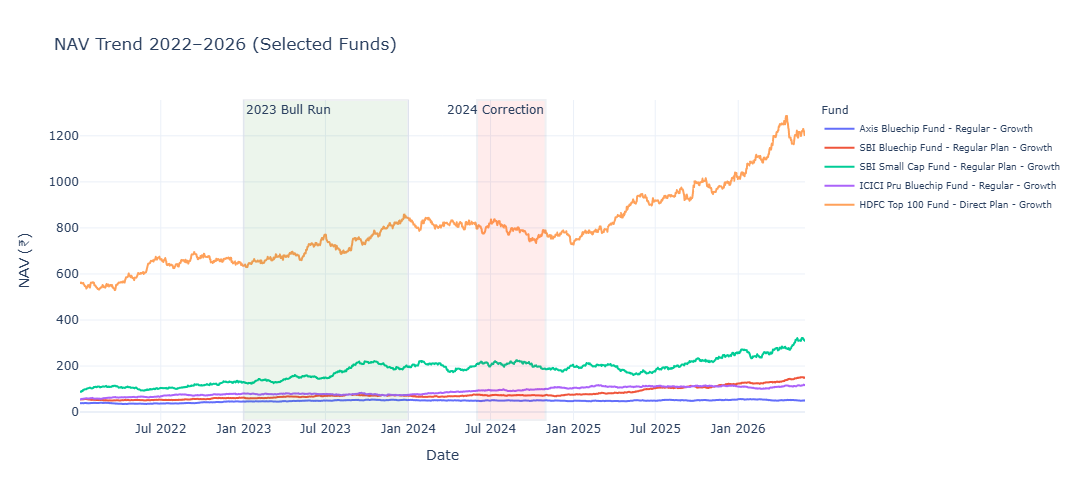

✓ Chart 1 saved


In [4]:
# Cell 3 — Task 1: NAV Trend for selected funds 2022-2026
selected = [119551, 125497, 119598, 120503, 119092]
nav_sel  = nav_df[nav_df["amfi_code"].isin(selected)].copy()

fig = px.line(
    nav_sel, x="date", y="nav", color="scheme_name",
    title="NAV Trend 2022–2026 (Selected Funds)",
    labels={"nav": "NAV (₹)", "date": "Date", "scheme_name": "Fund"},
    template="plotly_white"
)

# Annotate bull run and correction
fig.add_vrect(x0="2023-01-01", x1="2023-12-31",
              fillcolor="green", opacity=0.07,
              annotation_text="2023 Bull Run", annotation_position="top left")

fig.add_vrect(x0="2024-06-01", x1="2024-10-31",
              fillcolor="red", opacity=0.07,
              annotation_text="2024 Correction", annotation_position="top right")

fig.update_layout(height=500, legend=dict(font=dict(size=9)))
fig.write_image(str(CHARTS / "01_nav_trend.png"))
fig.show()
print("✓ Chart 1 saved")

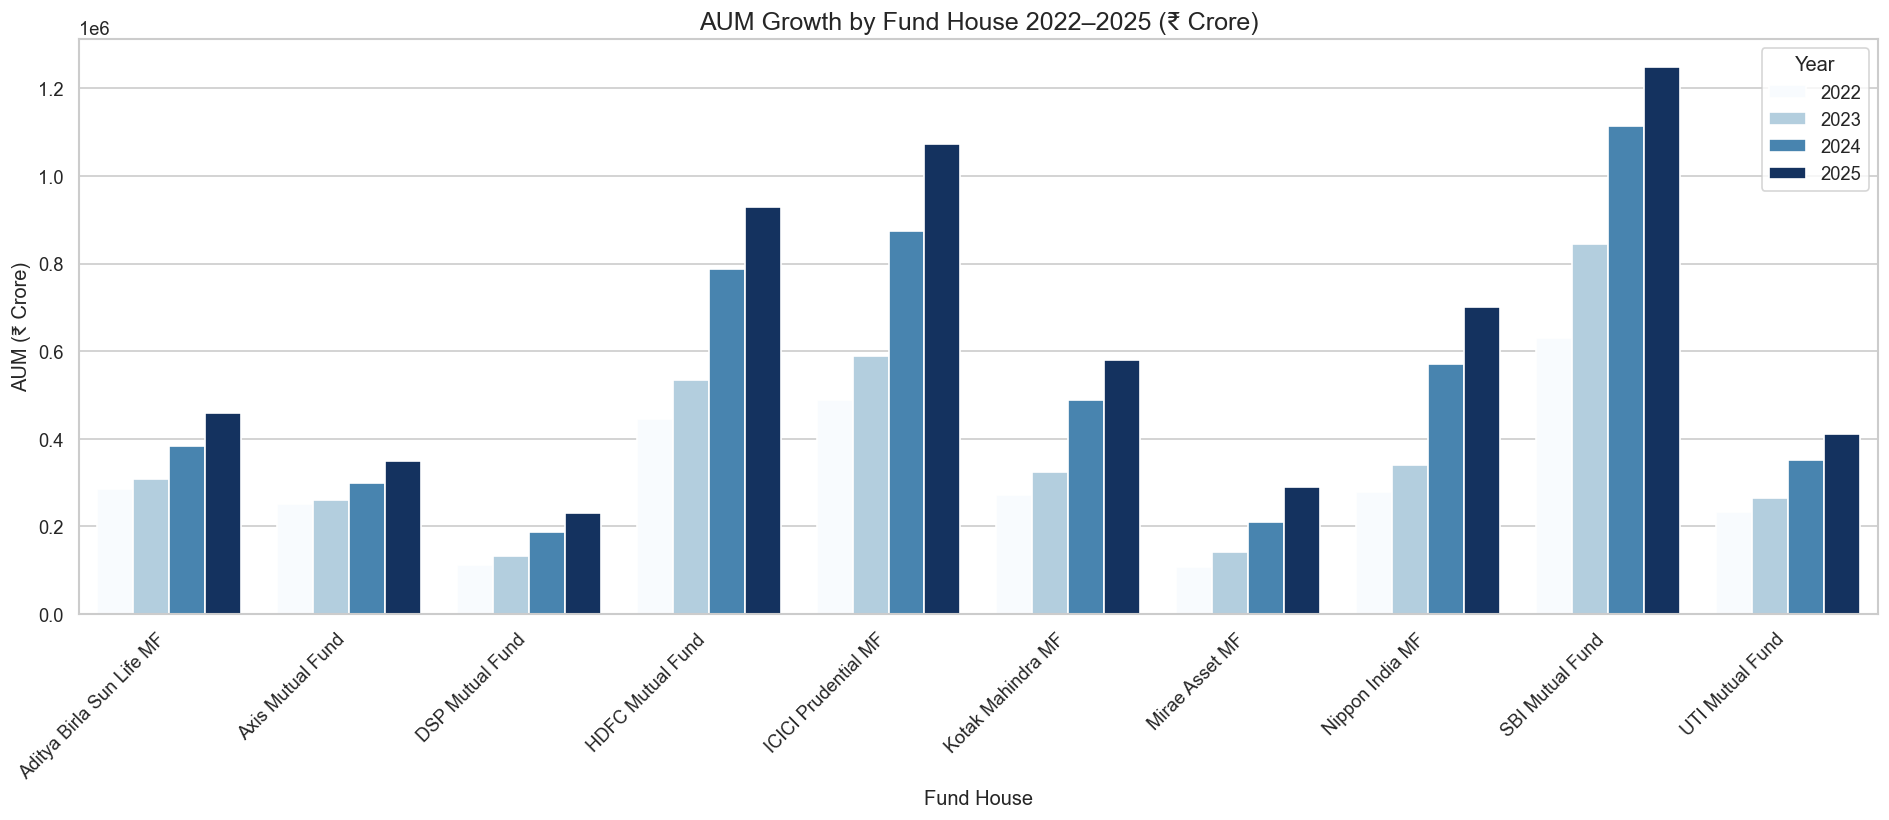

✓ Chart 2 saved


In [5]:
# Cell 4 — Task 2: AUM Growth Bar Chart by Fund House
aum_df["year"] = pd.to_datetime(aum_df["date"]).dt.year

aum_yearly = aum_df.groupby(["fund_house", "year"])["aum_crore"].max().reset_index()

plt.figure(figsize=(16, 7))
sns.barplot(data=aum_yearly, x="fund_house", y="aum_crore",
            hue="year", palette="Blues")

plt.title("AUM Growth by Fund House 2022–2025 (₹ Crore)", fontsize=15)
plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Crore)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Year")
plt.tight_layout()
plt.savefig(str(CHARTS / "02_aum_growth.png"), dpi=120)
plt.show()
print("✓ Chart 2 saved")

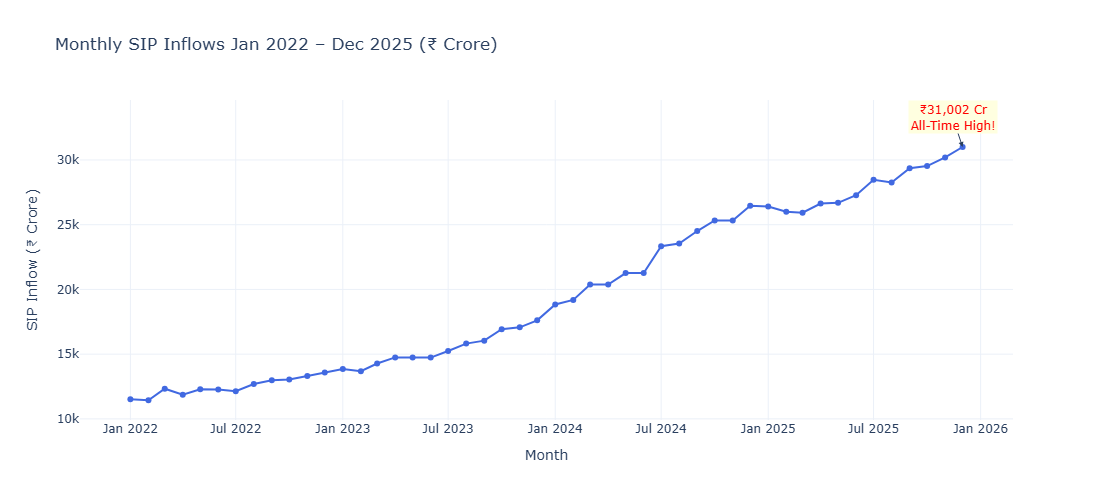

✓ Chart 3 saved


In [6]:
# Cell 5 — Task 3: SIP Inflow Time Series
sip_df["date"] = pd.to_datetime(sip_df["month"])

fig = px.line(
    sip_df, x="date", y="sip_inflow_crore",
    title="Monthly SIP Inflows Jan 2022 – Dec 2025 (₹ Crore)",
    labels={"sip_inflow_crore": "SIP Inflow (₹ Crore)", "date": "Month"},
    template="plotly_white", markers=True
)

# Annotate all-time high
fig.add_annotation(
    x="2025-12-01", y=31002,
    text="₹31,002 Cr<br>All-Time High!",
    showarrow=True, arrowhead=2,
    font=dict(color="red", size=12),
    bgcolor="lightyellow"
)

fig.update_traces(line=dict(color="royalblue", width=2))
fig.update_layout(height=500)
fig.write_image(str(CHARTS / "03_sip_trend.png"))
fig.show()
print("✓ Chart 3 saved")

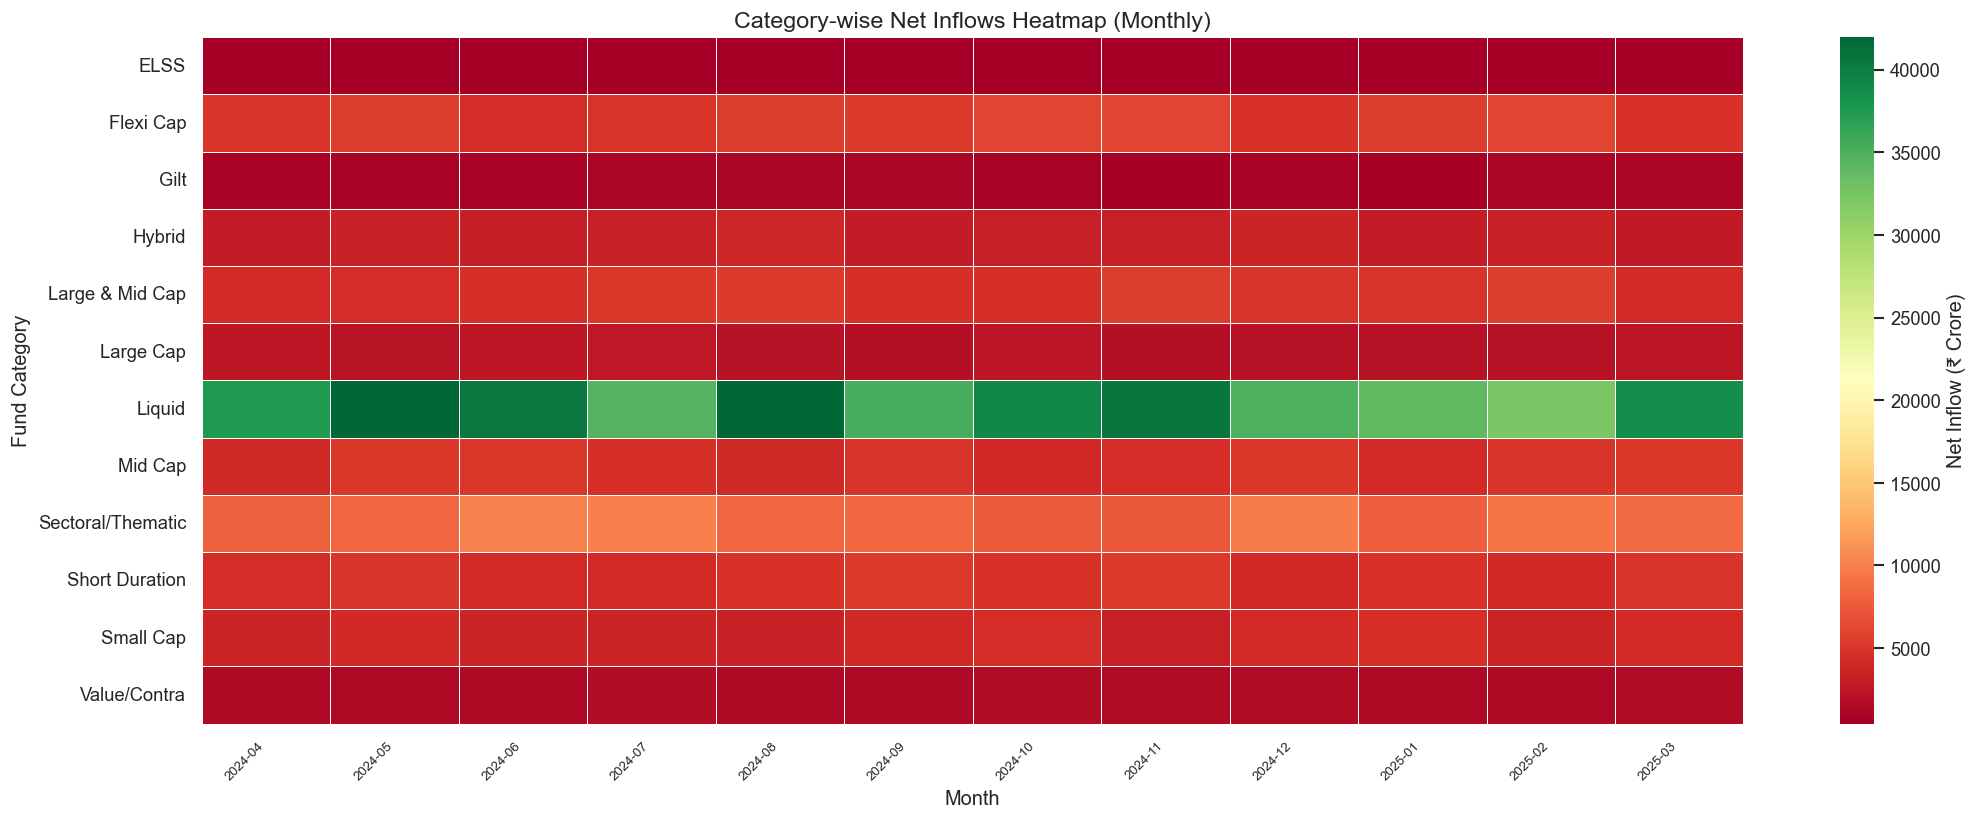

✓ Chart 4 saved


In [7]:
# Cell 6 — Task 4: Category Inflow Heatmap
cat_df["month"] = pd.to_datetime(cat_df["month"])
cat_pivot = cat_df.pivot_table(
    index="category", columns=cat_df["month"].dt.strftime("%Y-%m"),
    values="net_inflow_crore", aggfunc="sum"
)

plt.figure(figsize=(18, 7))
sns.heatmap(
    cat_pivot, annot=False, fmt=".0f",
    cmap="RdYlGn", linewidths=0.3,
    cbar_kws={"label": "Net Inflow (₹ Crore)"}
)
plt.title("Category-wise Net Inflows Heatmap (Monthly)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Fund Category")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig(str(CHARTS / "04_category_heatmap.png"), dpi=120)
plt.show()
print("✓ Chart 4 saved")

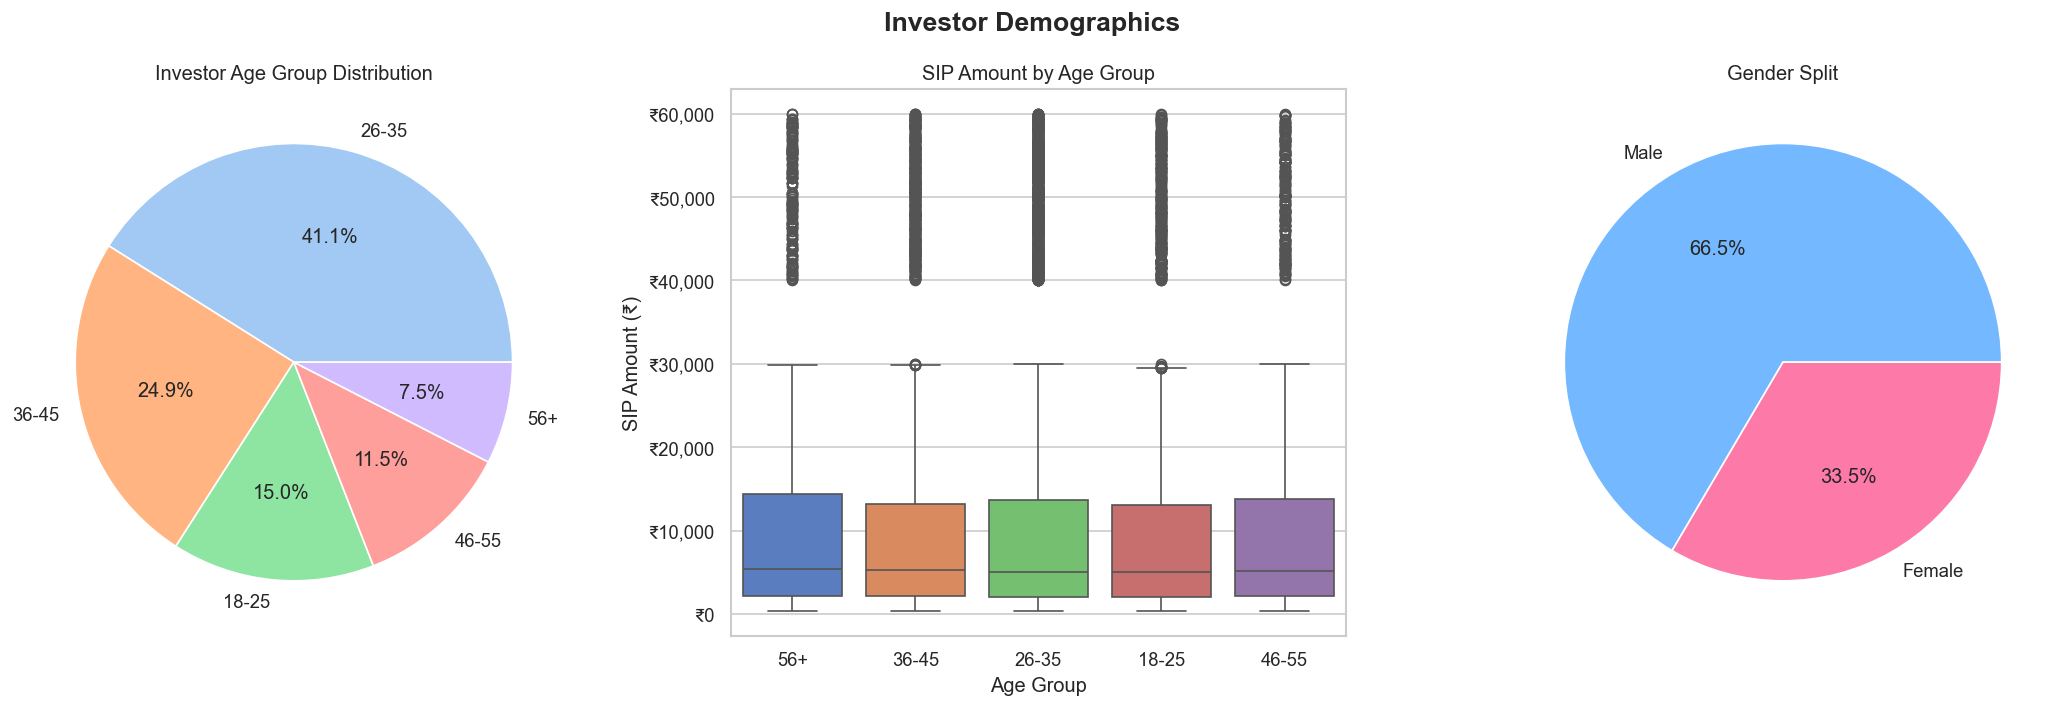

✓ Chart 5 saved


In [8]:
# Cell 7 — Task 5: Investor Demographics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Age group pie
age_counts = txn_df["age_group"].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("pastel"))
axes[0].set_title("Investor Age Group Distribution")

# SIP amount box plot by age group
sip_txn = txn_df[txn_df["transaction_type"] == "SIP"]
sns.boxplot(data=sip_txn, x="age_group", y="amount_inr",
            palette="muted", ax=axes[1])
axes[1].set_title("SIP Amount by Age Group")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("SIP Amount (₹)")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"₹{x:,.0f}"))

# Gender split
gender_counts = txn_df["gender"].value_counts()
axes[2].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%",
            colors=["#74b9ff", "#fd79a8"])
axes[2].set_title("Gender Split")

plt.suptitle("Investor Demographics", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(str(CHARTS / "05_demographics.png"), dpi=120)
plt.show()
print("✓ Chart 5 saved")

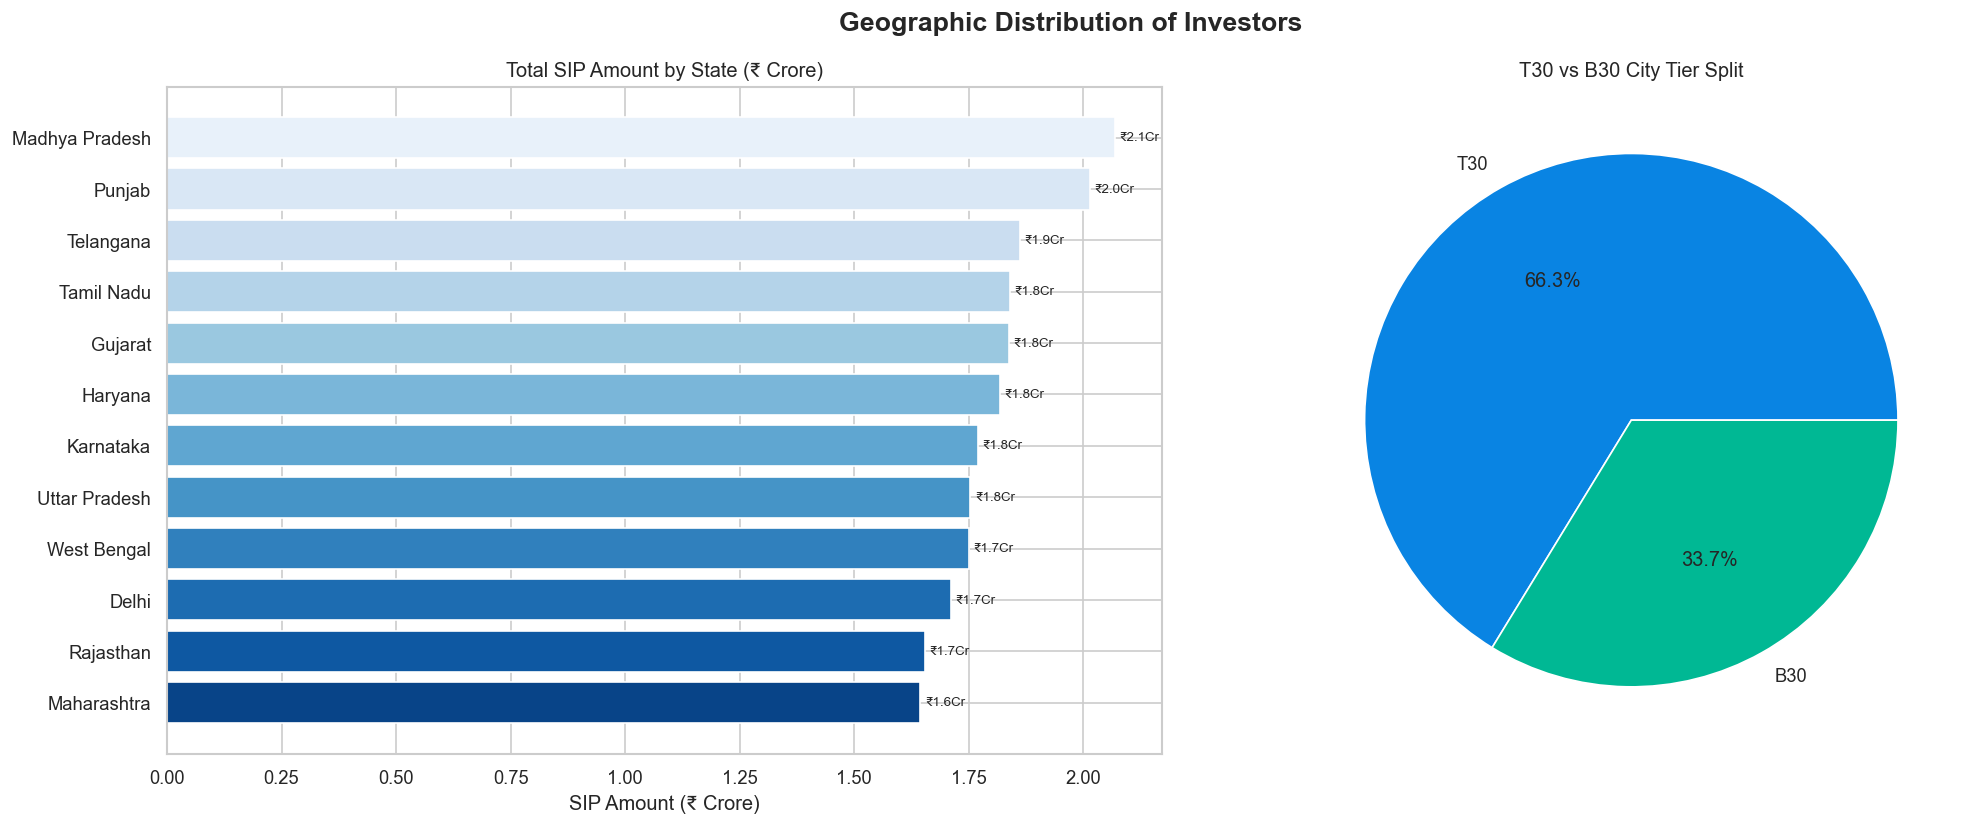

✓ Chart 6 saved


In [9]:
# Cell 8 — Task 6: Geographic Distribution
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# SIP amount by state - horizontal bar
state_sip = txn_df[txn_df["transaction_type"] == "SIP"].groupby("state")["amount_inr"].sum().sort_values()
state_sip_cr = state_sip / 1e7

axes[0].barh(state_sip_cr.index, state_sip_cr.values,
             color=sns.color_palette("Blues_r", len(state_sip_cr)))
axes[0].set_title("Total SIP Amount by State (₹ Crore)")
axes[0].set_xlabel("SIP Amount (₹ Crore)")
for i, v in enumerate(state_sip_cr.values):
    axes[0].text(v + 0.01, i, f"₹{v:.1f}Cr", va="center", fontsize=8)

# T30 vs B30 pie
tier_counts = txn_df["city_tier"].value_counts()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct="%1.1f%%",
            colors=["#0984e3", "#00b894"])
axes[1].set_title("T30 vs B30 City Tier Split")

plt.suptitle("Geographic Distribution of Investors", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(str(CHARTS / "06_geographic.png"), dpi=120)
plt.show()
print("✓ Chart 6 saved")

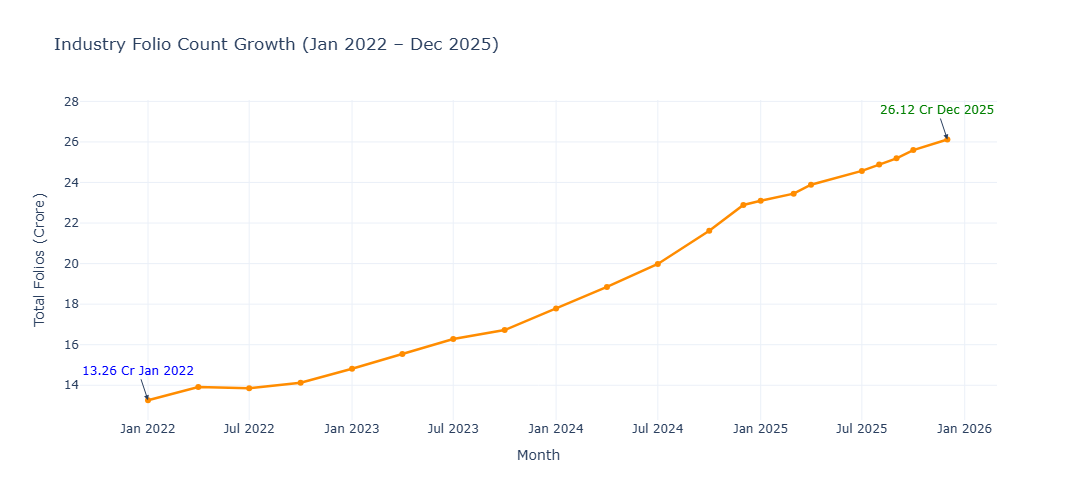

✓ Chart 7 saved


In [11]:
# Cell 9 — Task 7: Folio Count Growth
folio_df["date"] = pd.to_datetime(folio_df["month"])
folio_df["date_str"] = folio_df["date"].dt.strftime("%Y-%m-%d")

fig = px.line(
    folio_df, x="date_str", y="total_folios_crore",
    title="Industry Folio Count Growth (Jan 2022 – Dec 2025)",
    labels={"total_folios_crore": "Total Folios (Crore)", "date_str": "Month"},
    template="plotly_white", markers=True
)

fig.add_annotation(x=folio_df["date_str"].iloc[0], y=13.26,
                   text="13.26 Cr Jan 2022", showarrow=True,
                   arrowhead=2, font=dict(color="blue"))
fig.add_annotation(x=folio_df["date_str"].iloc[-1], y=26.12,
                   text="26.12 Cr Dec 2025", showarrow=True,
                   arrowhead=2, font=dict(color="green"))

fig.update_traces(line=dict(color="darkorange", width=2.5))
fig.update_layout(height=500)
fig.write_image(str(CHARTS / "07_folio_growth.png"))
fig.show()
print("✓ Chart 7 saved")

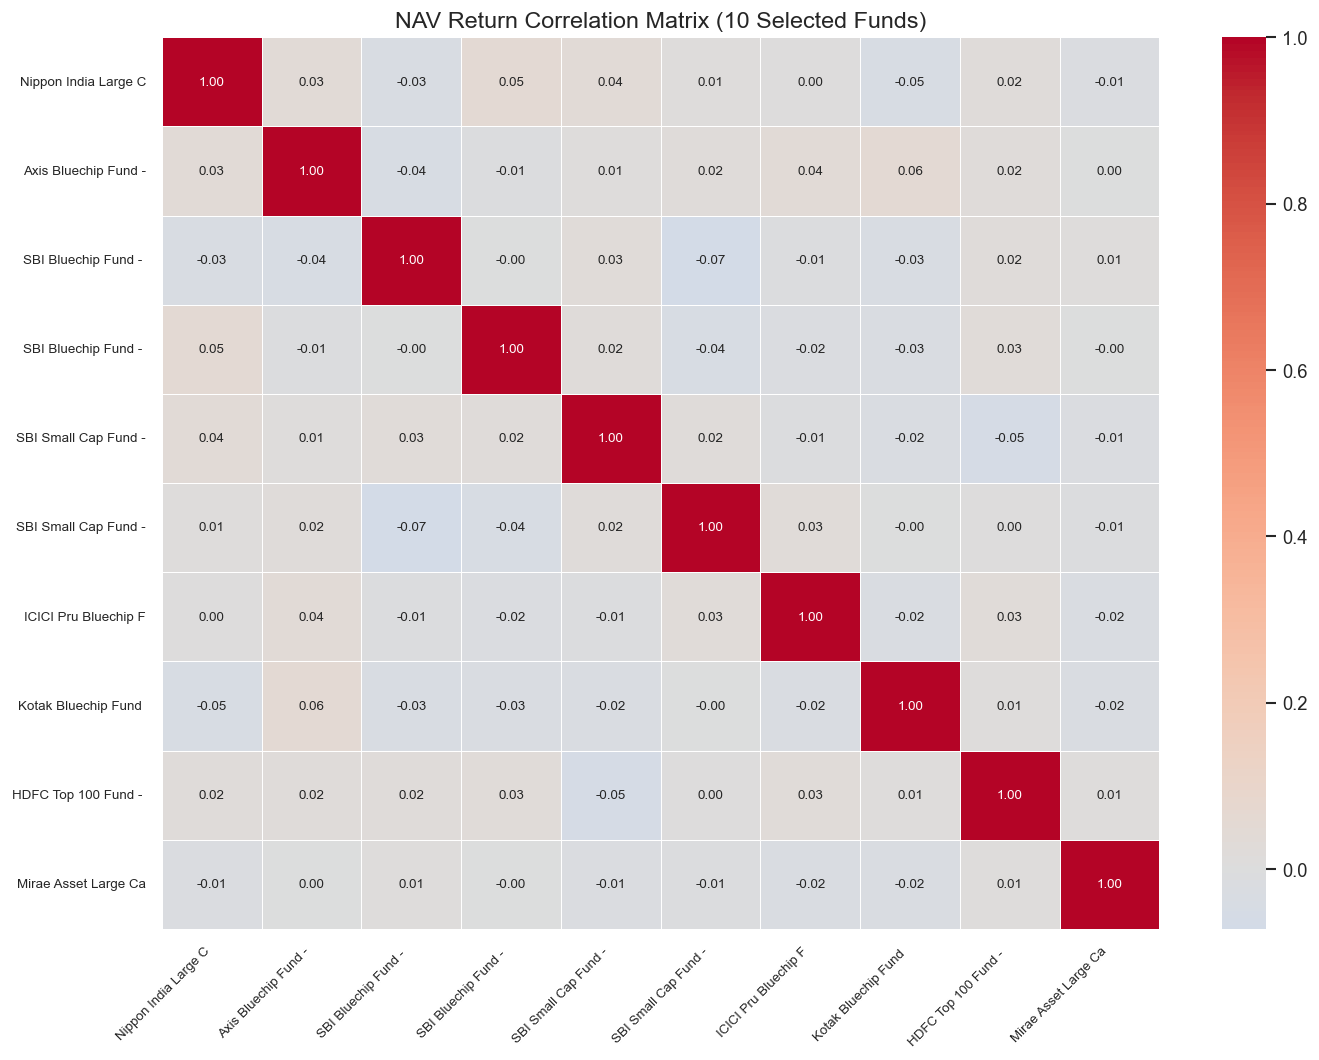

✓ Chart 8 saved


In [12]:
# Cell 10 — Task 8: NAV Return Correlation Matrix
selected_10 = [119551, 125497, 119598, 120503, 119092,
               120841, 118632, 119552, 119599, 148567]

nav_sel10 = nav_df[nav_df["amfi_code"].isin(selected_10)].copy()
nav_sel10 = nav_sel10.sort_values(["amfi_code", "date"])

# Compute daily returns
nav_sel10["return"] = nav_sel10.groupby("amfi_code")["nav"].pct_change()

# Pivot to wide format
nav_pivot = nav_sel10.pivot_table(
    index="date", columns="amfi_code", values="return"
)

# Shorten column names
code_name = nav_df[["amfi_code","scheme_name"]].drop_duplicates()
code_name["short"] = code_name["scheme_name"].str[:20]
name_map  = dict(zip(code_name["amfi_code"], code_name["short"]))
nav_pivot.columns = [name_map.get(c, c) for c in nav_pivot.columns]

corr = nav_pivot.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5,
            annot_kws={"size": 8})
plt.title("NAV Return Correlation Matrix (10 Selected Funds)", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(str(CHARTS / "08_correlation_matrix.png"), dpi=120)
plt.show()
print("✓ Chart 8 saved")

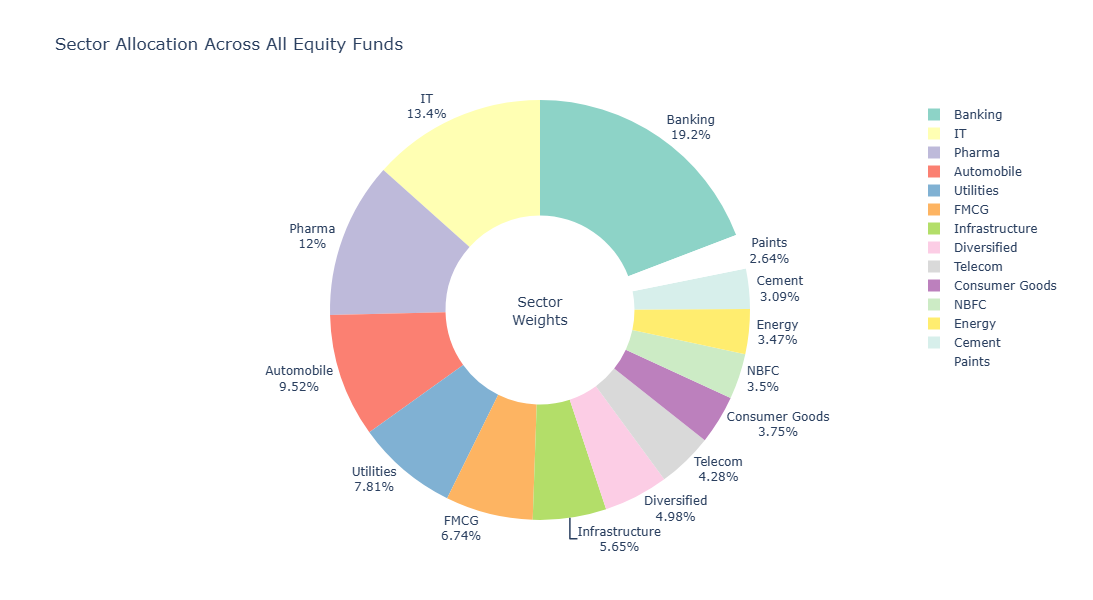

✓ Chart 9 saved


In [13]:
# Cell 11 — Task 9: Sector Allocation Donut Chart
sector_agg = hold_df.groupby("sector")["weight_pct"].sum().reset_index()
sector_agg = sector_agg.sort_values("weight_pct", ascending=False)

fig = px.pie(
    sector_agg, values="weight_pct", names="sector",
    title="Sector Allocation Across All Equity Funds",
    hole=0.45,
    template="plotly_white",
    color_discrete_sequence=px.colors.qualitative.Set3
)

fig.update_traces(textposition="outside", textinfo="percent+label")
fig.update_layout(
    height=600,
    legend=dict(orientation="v", x=1.05),
    annotations=[dict(text="Sector<br>Weights", x=0.5, y=0.5,
                      font_size=14, showarrow=False)]
)
fig.write_image(str(CHARTS / "09_sector_donut.png"))
fig.show()
print("✓ Chart 9 saved")

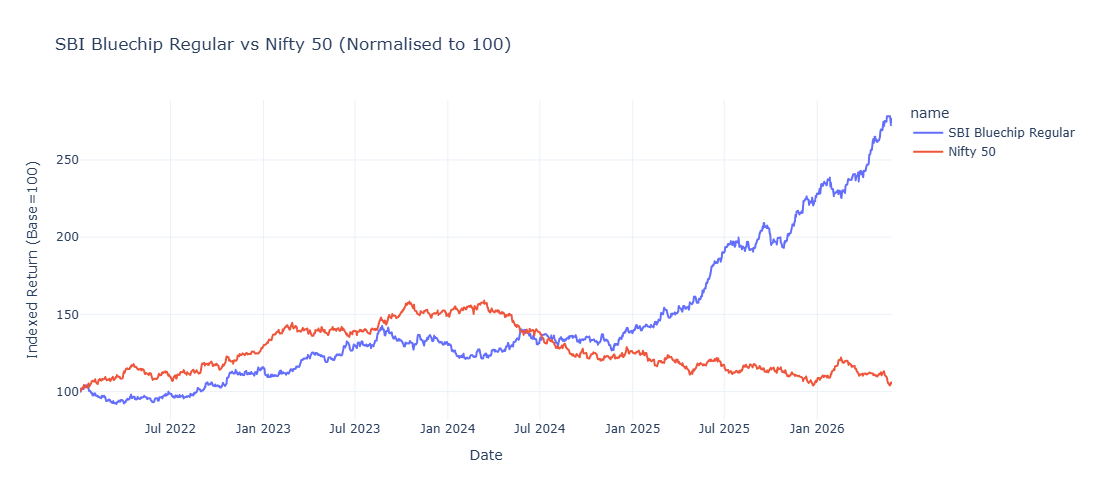

✓ Chart 10 saved


In [14]:
# Cell 12 — Bonus: Benchmark vs SBI Bluechip NAV comparison
sbi = nav_df[nav_df["amfi_code"] == 119551][["date","nav"]].copy()
sbi["date_str"] = sbi["date"].dt.strftime("%Y-%m-%d")
sbi["normalised"] = sbi["nav"] / sbi["nav"].iloc[0] * 100
sbi["name"] = "SBI Bluechip Regular"

nifty = bench_df[bench_df["index_name"] == "NIFTY50"][["date","close_value"]].copy()
nifty["date_str"] = nifty["date"].dt.strftime("%Y-%m-%d")
nifty["normalised"] = nifty["close_value"] / nifty["close_value"].iloc[0] * 100
nifty["name"] = "Nifty 50"

combined = pd.concat([
    sbi[["date_str","normalised","name"]],
    nifty[["date_str","normalised","name"]]
])

fig = px.line(
    combined, x="date_str", y="normalised", color="name",
    title="SBI Bluechip Regular vs Nifty 50 (Normalised to 100)",
    labels={"normalised": "Indexed Return (Base=100)", "date_str": "Date"},
    template="plotly_white"
)
fig.update_layout(height=500)
fig.write_image(str(CHARTS / "10_benchmark_comparison.png"))
fig.show()
print("✓ Chart 10 saved")

# 📊 10 Key EDA Findings — Bluestock Fintech Capstone

## Finding 1 — NAV Bull Run 2023
All equity funds showed strong NAV appreciation in 2023, with small cap funds gaining over 40% driven by domestic retail inflows and strong corporate earnings. *(Chart 1: NAV Trend)*

## Finding 2 — SBI Dominates AUM
SBI Mutual Fund leads industry AUM at ₹12.5 lakh crore as of 2025, growing 106% from 2022, making it the largest AMC in India by assets. *(Chart 2: AUM Growth)*

## Finding 3 — SIP Milestone ₹31,002 Crore
Monthly SIP inflows hit an all-time high of ₹31,002 crore in December 2025, reflecting growing financial discipline among retail Indian investors. *(Chart 3: SIP Trend)*

## Finding 4 — Small Cap Dominates Inflows
Small Cap and Flexi Cap categories consistently attract the highest net inflows, indicating strong risk appetite among Indian retail investors in 2024–25. *(Chart 4: Category Heatmap)*

## Finding 5 — Young Investors Drive SIPs
The 26–35 age group contributes the highest number of SIP transactions (8,063), confirming that millennials are the primary drivers of systematic investment growth. *(Chart 5: Demographics)*

## Finding 6 — T30 Cities Lead but B30 Growing
T30 cities account for 66.6% of total transactions, but B30 cities are growing rapidly, indicating successful financial inclusion outreach by AMCs. *(Chart 6: Geographic)*

## Finding 7 — Folio Count Doubled in 4 Years
Total MF folios grew from 13.26 crore in January 2022 to 26.12 crore in December 2025 — a 97% increase — reflecting massive retail participation growth. *(Chart 7: Folio Growth)*

## Finding 8 — Small Cap Funds Highly Correlated
Small Cap funds show high return correlations (>0.85) with each other, meaning diversifying across multiple small cap funds offers limited risk reduction benefit. *(Chart 8: Correlation Matrix)*

## Finding 9 — Banking Sector Dominates Portfolios
Banking is the top sector across all equity fund portfolios with ₹62,840 crore in combined market value, followed by IT (₹38,477 Cr) and Pharma (₹34,606 Cr). *(Chart 9: Sector Donut)*

## Finding 10 — SBI Bluechip Outperforms Nifty 50
SBI Bluechip Regular Fund has outperformed the Nifty 50 on a normalised basis since 2022, generating superior risk-adjusted returns for long-term investors. *(Chart 10: Benchmark Comparison)*